In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/datafile (2).csv")
df.head() 

In [30]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (55, 16)

Column names:
['Crop', 'Production 2006-07', 'Production 2007-08', 'Production 2008-09', 'Production 2009-10', 'Production 2010-11', 'Area 2006-07', 'Area 2007-08', 'Area 2008-09', 'Area 2009-10', 'Area 2010-11', 'Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09', 'Yield 2009-10', 'Yield 2010-11']

Data types:
Crop                      str
Production 2006-07    float64
Production 2007-08    float64
Production 2008-09    float64
Production 2009-10    float64
Production 2010-11    float64
Area 2006-07          float64
Area 2007-08          float64
Area 2008-09          float64
Area 2009-10          float64
Area 2010-11          float64
Yield 2006-07         float64
Yield 2007-08         float64
Yield 2008-09         float64
Yield 2009-10         float64
Yield 2010-11         float64
dtype: object

Missing values:
Crop                  0
Production 2006-07    0
Production 2007-08    0
Production 2008-09    0
Production 2009-10    0
Production 2010-11    0
Area 2

In [32]:
# Convert the dataset from wide format to a year-wise format

years = ['2006-07', '2007-08', '2008-09', '2009-10', '2010-11']

data_list = []

for year in years:
    temp = pd.DataFrame({
        'Crop': df['Crop'],
        'Year': year,
        'Production': df[f'Production {year}'],
        'Area': df[f'Area {year}'],
        'Yield': df[f'Yield {year}']
    })
    
    data_list.append(temp)

ml_data = pd.concat(data_list, ignore_index=True)

ml_data.head(10)

,Crop,Year,Production,Area,Yield
0,Total Foodgrains,2006-07,158.8,128.5,123.6
1,Rice,2006-07,200.8,168.5,119.2
2,Wheat,2006-07,131.6,115.0,114.4
3,Jowar,2006-07,124.3,120.7,103.0
4,Bajra,2006-07,136.4,94.5,144.3
5,Maize,2006-07,198.8,156.1,127.3
6,Ragi,2006-07,56.1,60.2,93.2
7,Small millets,2006-07,53.9,50.9,106.0
8,Barley,2006-07,88.1,72.8,121.0
9,Coarse Cereals,2006-07,138.5,106.4,130.1


In [33]:
ml_data.describe()

,Production,Area,Yield
count,275.000000,275.000000,275.000000
mean,183.042182,120.076000,152.415636
std,196.681803,44.902635,148.104507
min,42.100000,36.100000,72.700000
25%,116.650000,91.200000,111.700000
50%,155.400000,121.700000,124.600000
75%,199.050000,137.200000,151.350000
max,1790.600000,314.700000,1310.800000


In [34]:
print(ml_data['Crop'].nunique(), "unique crops")
print("\nYears:")
print(ml_data['Year'].unique())

print("\nCrop counts:")
print(ml_data['Crop'].value_counts().head(10))

55 unique crops

Years:
<StringArray>
['2006-07', '2007-08', '2008-09', '2009-10', '2010-11']
Length: 5, dtype: str

Crop counts:
Crop
Total Foodgrains    5
Rice                5
Wheat               5
Jowar               5
Bajra               5
Maize               5
Ragi                5
Small millets       5
Barley              5
Coarse Cereals      5
Name: count, dtype: int64


In [35]:
ml_data[['Production', 'Area', 'Yield']].corr()

,Production,Area,Yield
Production,1.000000,0.303585,0.950039
Area,0.303585,1.000000,0.001396
Yield,0.950039,0.001396,1.000000


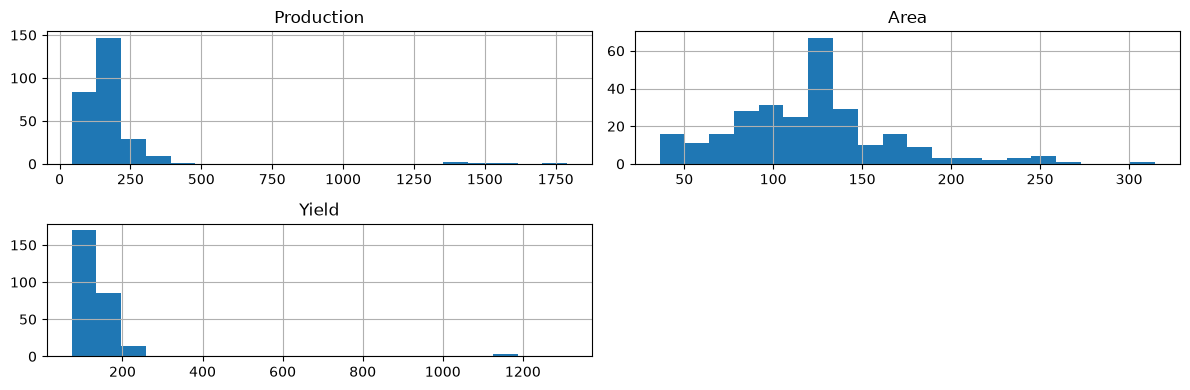

In [7]:
import matplotlib.pyplot as plt

ml_data[['Production', 'Area', 'Yield']].hist(
    bins=20,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/datafile (2).csv")

years = ['2006-07', '2007-08', '2008-09', '2009-10', '2010-11']

data_list = []

for year in years:
    temp = pd.DataFrame({
        'Crop': df['Crop'],
        'Year': year,
        'Production': df[f'Production {year}'],
        'Area': df[f'Area {year}'],
        'Yield': df[f'Yield {year}']
    })
    data_list.append(temp)

ml_data = pd.concat(data_list, ignore_index=True)

print("Dataset shape:", ml_data.shape)

Dataset shape: (275, 5)


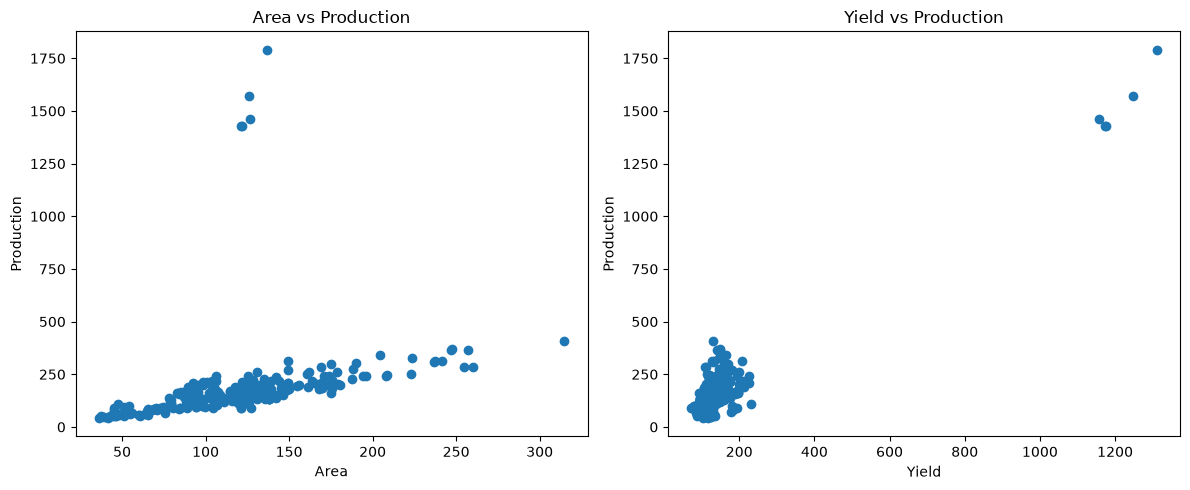

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(ml_data['Area'], ml_data['Production'])
axes[0].set_xlabel('Area')
axes[0].set_ylabel('Production')
axes[0].set_title('Area vs Production')

axes[1].scatter(ml_data['Yield'], ml_data['Production'])
axes[1].set_xlabel('Yield')
axes[1].set_ylabel('Production')
axes[1].set_title('Yield vs Production')

plt.tight_layout()
plt.show()

In [10]:
print(ml_data.shape)
print(ml_data.dtypes)
print(ml_data[['Production', 'Area', 'Yield']].head())

(275, 5)
Crop              str
Year              str
Production    float64
Area          float64
Yield         float64
dtype: object
   Production   Area  Yield
0       158.8  128.5  123.6
1       200.8  168.5  119.2
2       131.6  115.0  114.4
3       124.3  120.7  103.0
4       136.4   94.5  144.3


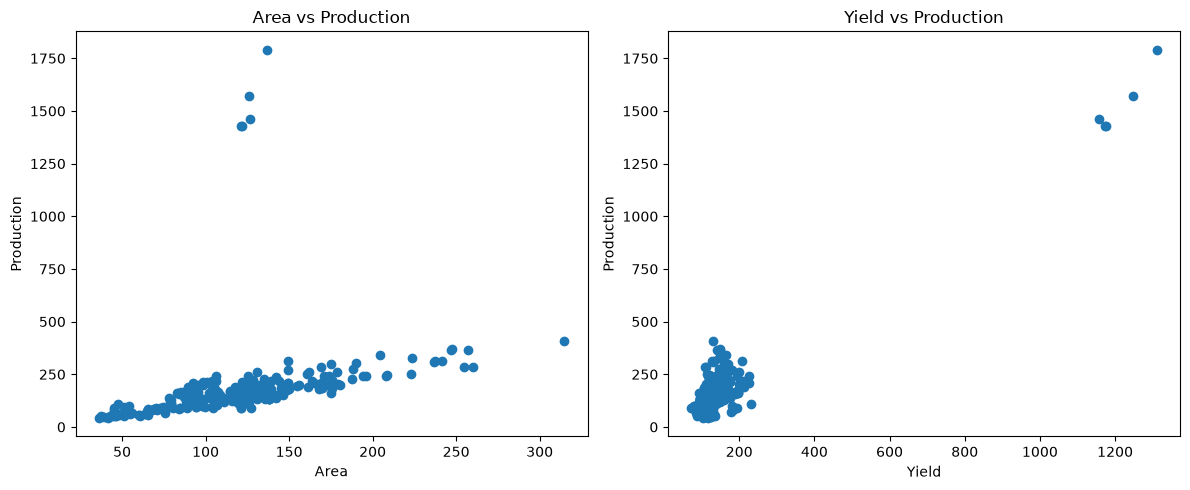

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(ml_data['Area'], ml_data['Production'])
axes[0].set_xlabel('Area')
axes[0].set_ylabel('Production')
axes[0].set_title('Area vs Production')

axes[1].scatter(ml_data['Yield'], ml_data['Production'])
axes[1].set_xlabel('Yield')
axes[1].set_ylabel('Production')
axes[1].set_title('Yield vs Production')

plt.tight_layout()
plt.show()

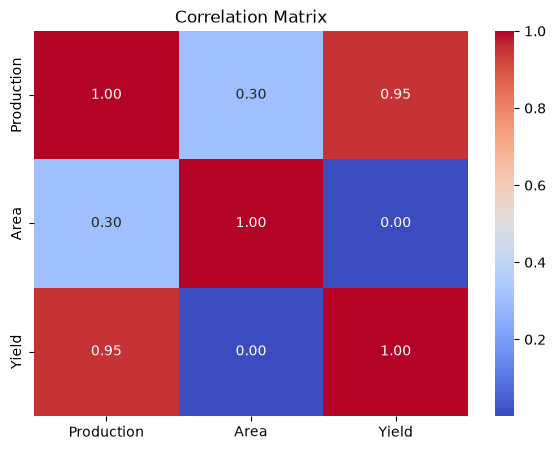

In [13]:
import seaborn as sns

plt.figure(figsize=(7, 5))

correlation = ml_data[['Production', 'Area', 'Yield']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [14]:
X = ml_data[['Area', 'Yield']]
y = ml_data['Production']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
    Area  Yield
0  128.5  123.6
1  168.5  119.2
2  115.0  114.4
3  120.7  103.0
4   94.5  144.3

Target:
0    158.8
1    200.8
2    131.6
3    124.3
4    136.4
Name: Production, dtype: float64

Feature shape: (275, 2)
Target shape: (275,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 220
Testing samples: 55


In [19]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [20]:
y_pred = model.predict(X_test)

print("Actual Production:")
print(y_test.head(10).to_numpy())

print("\nPredicted Production:")
print(y_pred[:10])

Actual Production:
[213.1 179.1 226.2 140.8  92.1 179.5 310.8 210.1 189.1  62.4]

Predicted Production:
[214.1039773  178.95822551 222.17492694 140.36806599  80.97446049
 178.91263517 292.33235309 207.35870953 217.23965538  48.28801226]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
MAE : 7.855755070204139
RMSE: 11.724542197245338
R² Score: 0.9602129899351267


In [22]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [23]:
rf_pred = rf_model.predict(X_test)

print("Actual Production:")
print(y_test.head(10).to_numpy())

print("\nRandom Forest Predictions:")
print(rf_pred[:10])

Actual Production:
[213.1 179.1 226.2 140.8  92.1 179.5 310.8 210.1 189.1  62.4]

Random Forest Predictions:
[206.77       177.08916667 218.852      141.091       94.39
 173.88       265.608      215.567      192.101       60.981     ]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation Results")
print("--------------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Evaluation Results
--------------------------------
MAE : 4.970051515151512
RMSE: 8.710652832954775
R² Score: 0.978039059974906


In [25]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,7.855755,11.724542,0.960213
1,Random Forest,4.970052,8.710653,0.978039


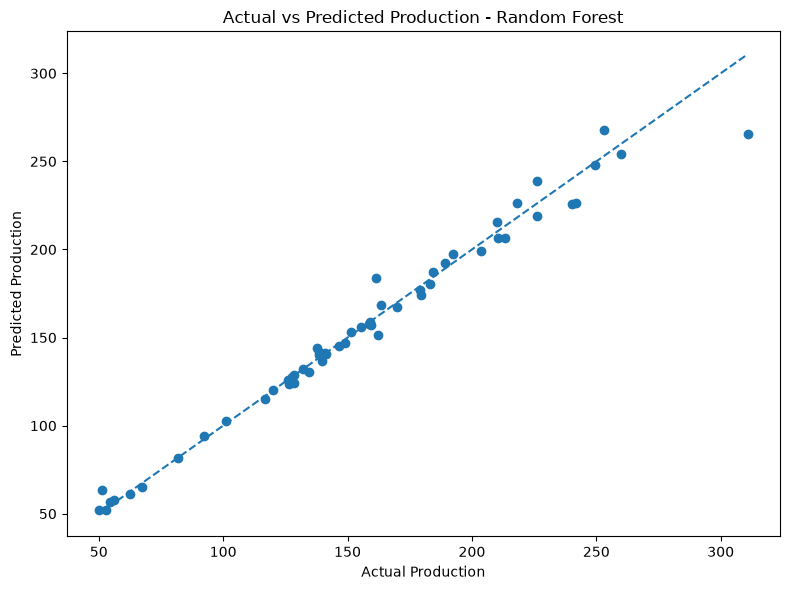

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Production')
plt.ylabel('Predicted Production')
plt.title('Actual vs Predicted Production - Random Forest')

# Perfect prediction reference line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.tight_layout()
plt.show()

  Feature  Importance
1   Yield     0.90573
0    Area     0.09427


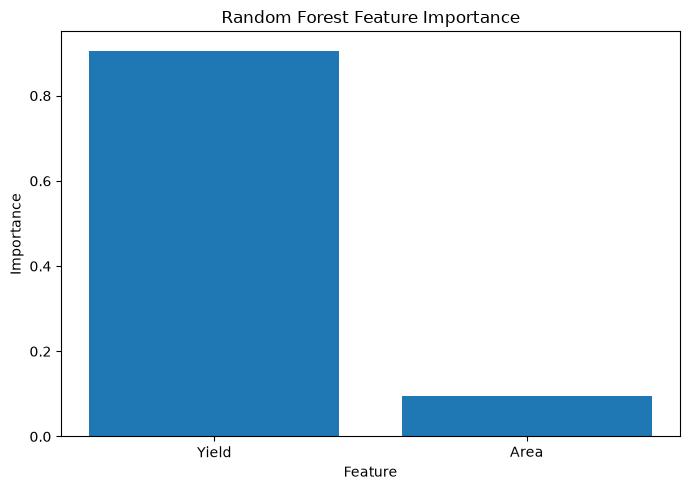

In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(7, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

In [30]:
import joblib

joblib.dump(rf_model, "agriculture_crop_production_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [31]:
sample_data = pd.DataFrame({
    'Area': [150],
    'Yield': [130]
})

sample_prediction = rf_model.predict(sample_data)

print("Input Area:", sample_data['Area'].iloc[0])
print("Input Yield:", sample_data['Yield'].iloc[0])
print("Predicted Production:", sample_prediction[0])

Input Area: 150
Input Yield: 130
Predicted Production: 201.60200000000003
